# Set Up

In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt 
from matplotlib.ticker import ScalarFormatter # per i ticks
import seaborn as sns

import pickle

# Impostare il seed dell'esperimento così da renderlo riproducibile
#np.random.seed(seed=4)

# region Importazione JSON di configurazione
import json
import sys
path_config =   r"/Users/mattia/Desktop/Università/Data Science in Python"
# Importazione file di configurazione classico
with open(f'{path_config}/config.json', 'r') as file:
    config = json.load(file)
sys.path.append(config["path_python_pacchetti"]) # aggiunta pacchetti classici
# endregion

path_risultati = r"/Users/mattia/Desktop/Università/Data Science in Python/_Progetti/Solitari/Solitario123"

from formattazione_testo import formatta_percentuali,formatta_numeri
from LaTeX import LaTeX

from funzioni_solitario123 import __simulazione_solitario123_vettorializzata__

In [2]:
# Inizializzare la classe per il report .tex poi pdf
doc = LaTeX(formato="V",
            titolo_report="Tasso di successo del solitario 123",
            indice=False,
            separazione_header_contenuto=False,
            separazione_title_indice=False,
            autore="Mattia",
            data="\\today",
            geometry='left= 3.81cm,right=2.54cm,top=2.54cm,bottom=3.81cm',
            numerazione_pagine = "fancy",
            linguaggio='italiano',
            toc_depth= 3
)

# Descrizione del solitario

Il solitario chiamato 1, 2 ... 3 si gioca con un mazzo di carte italiane (40 carte divise in 4 semi, ogni seme va da 1 al 10).   
Dopo aver mescolato le carte si prende la prima carta del mazzo, se questa è un asso (1) si perde la partita,
se non lo è si va alla seconda. Se questa è un 2 si perde la partita, altrimenti si va alla terza. Se la terza è un 3 si perde, altrimenti si va alla carta successiva e si rinizia il conteggio se è 1 perso....

In questo script si simula il gioco del solitario X volte per cercare di stimare tramite bootstrap le probabilità di successo non riuscendo a calcolarle tramite la probabilità classica data la natura complessa del solitario. 

In [3]:
doc.text("""Il solitario chiamato 1, 2 ... 3 si gioca con un mazzo di carte italiane (40 carte divise in 4 semi, ogni seme va da 1 al 10).   
Dopo aver mescolato le carte si prende la prima carta del mazzo, se questa è un asso (1) si perde la partita,
se non lo è si va alla seconda. Se questa è un 2 si perde la partita, altrimenti si va alla terza. Se la terza è un 3 si perde, altrimenti si va alla carta successiva e si rinizia il conteggio se è 1 perso....""")

# Effettuo il "bootstrap"

Effettuo diverse simulazioni con un numero di prove diverse per capire se il tasso di successo converge.

In [4]:
# Numero di prove per ogni simulazione.
simulazioni = [100,
               1000,
               10000,
               100000,
               1000000,
               10000000
              ]

# Inizializzo il dizionario che conterrà i risultati delle simulazioi
risultati_simulazioni_n_vittorie = {}
risultati_simulazioni_tasso_successo = {}

doc.section("Simulazioni") # aggiungo una sezione 

# Iterare per effettuare le simulazioni
for numero_prove in simulazioni:
   
   # Inizializzo il numero di vittore per simulazione
   vittorie = 0

   # aggiungo al file .tex una sottosezione per la simulazion i-esima
   doc.subsection(f"Simulazione con {formatta_numeri(numero_prove)} prove")
   
   # Per l' i-esima simulazione effettuo le N prove specificate
   vittorie = __simulazione_solitario123_vettorializzata__(n_prove=numero_prove)

   # Calcolo il tasso di successo
   tasso_di_successo = (vittorie/numero_prove)*100
   
   # Creo un output testuale descrivente i risultati per la i-esima simulazione con le N prove specificate
   risultato_testuale = f"Su {formatta_numeri(numero_prove)} prove il solitario è stato vinto {formatta_numeri(vittorie)} volte.\nTasso di successo {formatta_percentuali(tasso_di_successo,formattazione_italiana=True,decimali=2,percentuale=False)}\%\n"

   doc.text(risultato_testuale) # Aggiungo l'output testuale al file .tex
   print(risultato_testuale.replace("\\","")) 
   
   # Assegno i risultati della simulazione 
   risultati_simulazioni_n_vittorie[numero_prove] = vittorie
   
   risultati_simulazioni_tasso_successo[numero_prove] = tasso_di_successo
   

Su 100 prove il solitario è stato vinto 0 volte.
Tasso di successo 0,00%

Su 1.000 prove il solitario è stato vinto 7 volte.
Tasso di successo 0,70%

Su 10.000 prove il solitario è stato vinto 90 volte.
Tasso di successo 0,90%

Su 100.000 prove il solitario è stato vinto 838 volte.
Tasso di successo 0,84%

Su 1.000.000 prove il solitario è stato vinto 8.462 volte.
Tasso di successo 0,85%

Su 10.000.000 prove il solitario è stato vinto 82.737 volte.
Tasso di successo 0,83%



# Grafico iterazioni-successo

Importare i dati simulati in separata instanza.

In [5]:
with open(f"{path_risultati}/Risultati/risultati_simulazioni_tasso_successo.pkl", "rb") as f:
   risultati_simulazioni_tasso_successo = pickle.load(f)
    
with open(f"{path_risultati}/Risultati/risultati_simulazioni_tasso_successo.pkl", "rb") as f:
   risultati_simulazioni_n_vittorie = pickle.load(f)

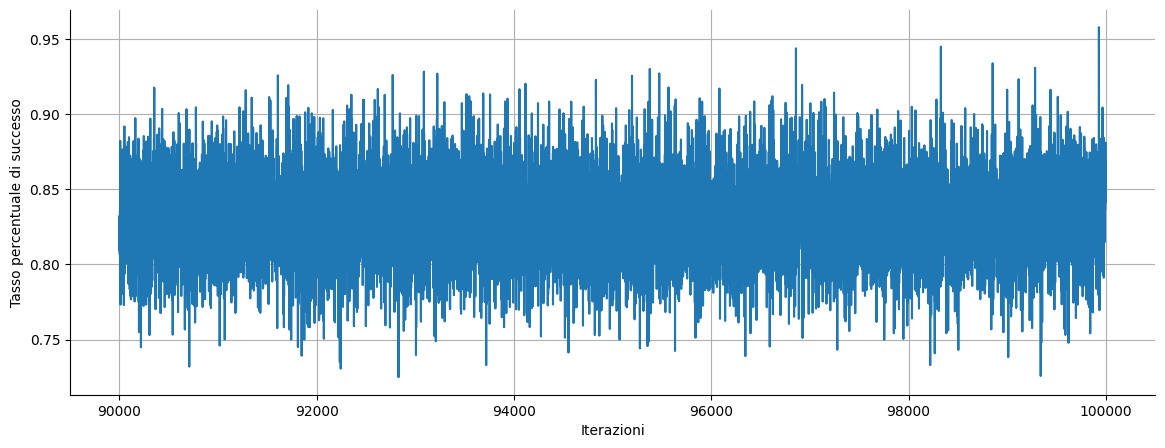

In [6]:
x = list(risultati_simulazioni_tasso_successo.keys())
y = list(risultati_simulazioni_tasso_successo.values())

fig = plt.figure()               
plt.gcf().set_size_inches((14, 5)) 
plt.plot(x,y)
# Set plot labels and title
plt.xlabel('Iterazioni', fontsize=10)
plt.ylabel('Tasso percentuale di successo', fontsize=10)
#plt.title('Tasso di successo del solitario 123', fontsize=15)

ax = plt.gca()
formatter = ScalarFormatter(useOffset=False)
formatter.set_scientific(False)
ax.xaxis.set_major_formatter(formatter)
sns.despine()
plt.grid()
path_figura = f"{path_risultati}/Immagini/Grafico_iterazioni-tassoSuccesso.png"
fig.savefig(path_figura, bbox_inches="tight",dpi=300) # Salvare una figura+
doc.image(path=path_figura,
          scale=0.51,
          title = "Tasso di successo per ogni iterazione",
          titolo_alto =True,
          numerare_figura = True,
          centering=True,
          offset = 0,
          label = "fig:SociPerTipologia"
          )

plt.show()

# Esportazioni risultati

In [7]:
doc.export(path=f"{path_risultati}/RisultatiSimulazioniSolitario123.tex",
            knit=True,
            overwrite=True
            )